## Importing necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sqlite3

df_m = pd.read_csv("../data_files/executions.csv")
df_h = pd.read_csv("../data_files/historical_execution_data.txt")

## Cleaning historical execution dataset

In [2]:
df_h.head()

,V5,V6,V7,V10,V11,V12,V13,V14,V16,V19,V21
0,1,,NORMAN ELI,1,1,19,12,1812,1,1,250
1,1,,WOODS JOHN,44,4,6,2,1814,1,1,616
2,2,,GAMARRA CHARLES,13,1,19,5,1820,1,1,
3,2,,DESAYAS VICTORIANO,1,1,19,5,1820,1,1,
4,2,,NOREAGO FRANCISCO,1,1,30,5,1822,1,1,187


In [3]:
col_to_move = df_h.pop('V19')
df_h.insert(1, 'V19', col_to_move)

In [4]:
df_h.columns = ['race', 'sex', 'age', 'name', 'crime_com', 'exec_method', 'date_day', 'date_month', 'date_year', 'state', 'off_occ']

In [5]:
df_h = df_h.sort_values(by='date_year')

In [6]:
df_h['age'] = pd.to_numeric(df_h['age'], errors='coerce').fillna(0).astype(int)
df_h['race'] = df_h['race'].replace({
    '1': 'White',
    '2': 'Black',
    '3': 'Native Am',
    '4': 'Asian-Pac-Il',
    '5': 'Hispanic',
    '6': 'Other',
    ' ': 'Unknown'
    })
df_h['sex'] = df_h['sex'].replace({'1': 'Male', '2': 'Female', ' ': 'Unknown'})

In [7]:
df_h['crime_com'] = df_h['crime_com'].str.strip()
df_h['crime_com'] = df_h['crime_com'].replace({
    '1': 'Murder',
    '2': 'Rape',
    '3': 'Criminal Assault',
    '4': 'HouseBrkng-Burgl',
    '5': 'Horse Stealing',
    '6': 'Consp to Murder',
    '7': 'Treason',
    '8': 'Slave Revolt',
    '9': 'Witchcraft',
    '10': 'Robbery-Murder',
    '11': 'Rape-Murder',
    '12': 'Piracy',
    '13': 'Accessory to Mur',
    '14': 'Desertion',
    '15': 'Robbery',
    '16': 'Arson',
    '17': 'Guerilla Activity',
    '18': 'Spying-Espionage',
    '19': 'Murder-Rape-Rob',
    '20': 'Burg-Att Rape',
    '21': 'Rioting',
    '22': 'Attempted Rape',
    '23': 'Murder-Burglary',
    '24': 'Kidnap-Murder',
    '25': 'Kidnap-Murder-Rob',
    '26': 'Arson-Murder',
    '27': 'Rape-Robbery',
    '28': 'Kidnapping',
    '29': 'Prisn Brk-Kidnap',
    '30': 'Sodmy-Buggry-Bst',
    '31': 'Adultery',
    '33': 'Poisoning',
    '35': 'Concealing Birth',
    '36': 'Unspec Felony',
    '37': 'Aid Runaway Slave',
    '39': 'Counterfeiting',
    '40': 'Attempted Murder',
    '41': 'Forgery',
    '43': 'Theft-Stealing',
    '44': 'Other',
    '': 'Unknown',
})

In [8]:
df_h['exec_method'] = df_h['exec_method'].str.strip()
df_h['exec_method'] = df_h['exec_method'].replace({
    '1': 'Hanging',
    '2': 'Electrocution',
    '3': 'Asphyxiation-Gas',
    '4': 'Shot',
    '5': 'Injection',
    '6': 'Pressing',
    '8': 'Break on Wheel',
    '10': 'Burned',
    '11': 'Hung in Chains',
    '13': 'Bludgeoned',
    '14': 'Gibbetted',
    '15': 'Other',
    '': 'Unknown'
})

In [9]:
df_h['off_occ'] = df_h['off_occ'].str.strip()
df_h['off_occ'] = df_h['off_occ'].replace({
    '610': 'Slave',
    '355': 'Laborer',
    '236': 'Farm Hand',
    '241': 'Farmer',
    '160': 'Convict',
    '224': 'Ex Convict',
    '237': 'Farm Laborer',
    '465': 'Parolee',
    '417': 'Miner',
    '616': 'Soldier',
    '272': 'Gangster',
    '220': 'Escaped Convict',
    '591': 'Seaman',
    '173': 'Criminal',
    '475': 'Pirate',
    '654': 'Tenant Farmer',
    '271': 'Gang Member',
    '108': 'Carpenter',
    '328': 'Housewife',
    '689': 'Truck Driver',
    '530': 'Railroad Worker',
    '259': 'Freedman',
    '': 'Unknown'})

In [10]:
df_h['state'] = df_h['state'].astype(str)
df_h['state'] = df_h['state'].replace({
'1': 'AL',
'2': 'AK',
'4': 'AZ',
'5': 'AR',
'6': 'CA',
'8': 'CO',
'9': 'CT',
'10': 'DE',
'11': 'W.D.C.',
'12': 'FL',
'13': 'GA',
'15': 'HI',
'16': 'ID',
'17': 'IL',
'18': 'IN',
'19': 'IA',
'20': 'KS',
'21': 'KY',
'22': 'LA',
'23': 'ME',
'24': 'MD',
'25': 'MA',
'26': 'MI',
'27': 'MN',
'28': 'MS',
'29': 'MO',
'30': 'MT',
'31': 'NE',
'32': 'NV',
'33': 'NH',
'34': 'NJ',
'35': 'NM',
'36': 'NY',
'37': 'NC',
'38': 'ND',
'39': 'OH',
'40': 'OK',
'41': 'OR',
'42': 'PA',
'44': 'RI',
'45': 'SC',
'46': 'SD',
'47': 'TN',
'48': 'TX',
'49': 'UT',
'50': 'VT',
'51': 'VA',
'53': 'WA',
'54': 'WV',
'55': 'WI',
'56': 'WY'})

### Creating pre-1977 variable for historical data to prevent overlap during concatenation with modern dataset.

In [11]:
df_h_pre1977 = df_h[df_h['date_year'] < 1977]
df_h_pre1977.tail()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
4388,White,Male,23,YORK GEORGE,Robbery-Murder,Hanging,22,6,1965,KS,Soldier
707,White,Male,33,BOWEN WILLIAM JR,Murder,Electrocution,15,1,1965,AL,467
9987,White,Male,30,FRENCH JAMES,Murder,Electrocution,10,8,1966,OK,Convict
2120,Hispanic,Male,48,MONGE LUIS,Murder,Asphyxiation-Gas,2,6,1967,CO,12
2019,Black,Male,37,MITCHELL AARON,Murder,Asphyxiation-Gas,12,4,1967,CA,460


## Cleaning modern execution dataset

In [12]:
df_m = df_m.drop(columns=['Number of White Male Victims',
       'Number of Black Male Victims', 'Number of Latino Male Victims',
       'Number of Asian Male Victims',
       'Number of Native American Male Victims',
       'Number of Other Race Male Victims', 'Number of White Female Victims',
       'Number of Black Female Victims', 'Number of Latino Female Victims',
       'Number of Asian Female Victims',
       'Number of American Indian or Alaska Native Female Victims',
       'Number of Other Race Female Victims', 'Victim Races Includes White'])

In [13]:
df_m.rename(columns={'Number of Victims': 'num_vics',
                     'Number of Male Victims': 'num_male_vics',
                     'Number of Female Victims': 'num_female_vics'}, inplace=True)

In [14]:
col_to_move = df_m.pop('Middle Name(s)')
df_m.insert(1, 'Middle Name(s)', col_to_move)
df_m.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,Country,State,County,Execution Date,Method,Victims,Victim Races,num_vics,num_male_vics,num_female_vics
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,United States,Utah,Utah County,01/17/1977,Firing Squad,1 White Male,White,1,1,0
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,United States,Florida,Leon County,05/25/1979,Electrocution,1 White Male,White,1,1,0
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,United States,Nevada,Clark County,10/22/1979,Gas,1 White Male,White,1,1,0
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,United States,Indiana,Morgan County,03/09/1981,Electrocution,"2 White Females, 2 White Males",White,4,2,2
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,United States,Virginia,Newport News city,08/10/1982,Electrocution,1 White Male,White,1,1,0


In [15]:
df_h['execution_date'] = pd.to_datetime(
    dict(year=df_h['date_year'], month=df_h['date_month'], day=df_h['date_day']),
    errors='coerce')

In [16]:
df_h.head()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ,execution_date
13062,White,Male,0,KENDALL GEORGE,Spying-Espionage,Shot,,,1608,VA,166,NaT
13063,White,Male,0,FRANK DANIELL,Theft-Stealing,Hanging,1,3,1622,VA,331,1622-03-01
13064,White,Male,0,CORNISH RICHARD,Sodmy-Buggry-Bst,Hanging,,,1624,VA,Unknown,NaT
13065,White,Male,21,HAYLE THOMAS,Rape,Hanging,6,,1626,VA,Unknown,NaT
5795,White,Male,40,BILLINGTON JOHN,Murder,Hanging,30,9,1630,MA,Unknown,1630-09-30


In [17]:
df_h['execution_date'].dtype

dtype('<M8[us]')

In [18]:
df_m['Execution Date'] = pd.to_datetime(df_m['Execution Date'])
df_m['year'] = df_m['Execution Date'].dt.year

In [19]:
df_m.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,State,County,Execution Date,Method,Victims,Victim Races,num_vics,num_male_vics,num_female_vics,year
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,Utah,Utah County,1977-01-17,Firing Squad,1 White Male,White,1,1,0,1977
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,Florida,Leon County,1979-05-25,Electrocution,1 White Male,White,1,1,0,1979
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,Nevada,Clark County,1979-10-22,Gas,1 White Male,White,1,1,0,1979
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,Indiana,Morgan County,1981-03-09,Electrocution,"2 White Females, 2 White Males",White,4,2,2,1981
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,Virginia,Newport News city,1982-08-10,Electrocution,1 White Male,White,1,1,0,1982


In [20]:
df_m['Execution Date'].dtype

dtype('<M8[us]')

In [21]:
df_m['Age'].dtype

dtype('int64')

In [22]:
df_m.columns

Index(['First Name', 'Middle Name(s)', 'Last Name', 'Suffix', 'Race', 'Sex',
       'Age', 'Foreign National', 'Juvenile', 'Federal', 'Region', 'Country',
       'State', 'County', 'Execution Date', 'Method', 'Victims',
       'Victim Races', 'num_vics', 'num_male_vics', 'num_female_vics', 'year'],
      dtype='str')

In [23]:
col_to_move2 = df_m.pop('year')
df_m.insert(15, 'year', col_to_move2)

df_m.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,State,County,Execution Date,year,Method,Victims,Victim Races,num_vics,num_male_vics,num_female_vics
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,Utah,Utah County,1977-01-17,1977,Firing Squad,1 White Male,White,1,1,0
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,Florida,Leon County,1979-05-25,1979,Electrocution,1 White Male,White,1,1,0
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,Nevada,Clark County,1979-10-22,1979,Gas,1 White Male,White,1,1,0
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,Indiana,Morgan County,1981-03-09,1981,Electrocution,"2 White Females, 2 White Males",White,4,2,2
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,Virginia,Newport News city,1982-08-10,1982,Electrocution,1 White Male,White,1,1,0


## Creating SQL Schemas

In [24]:
# Make updated dataframes, include ALL columns for both datasets, make irrelevant columns NULL, then combine into one dataframe.

historical_data = pd.DataFrame({
    'race': df_h_pre1977['race'],
    'sex': df_h_pre1977['sex'],
    'age': df_h_pre1977['age'],
    'crime_com': df_h_pre1977['crime_com'],
    'exec_method': df_h_pre1977['exec_method'],
    'date_year': df_h_pre1977['date_year'],
    'state': df_h_pre1977['state'],
    'off_occ': df_h_pre1977['off_occ'],
    'foreign_national': pd.NA,
    'juvenile': pd.NA,
    'federal': pd.NA,
    'region': pd.NA,
    'victims': pd.NA,
    'victim_races': pd.NA,
    'num_vics': pd.NA,
    'num_male_vics': pd.NA,
    'num_female_vics': pd.NA,
    })

modern_data = pd.DataFrame({
    'race': df_m['Race'],
    'sex': df_m['Sex'],
    'age': df_m['Age'],
    'crime_com': pd.NA,
    'exec_method': df_m['Method'],
    'date_year': df_m['year'],
    'state': df_m['State'],
    'off_occ': pd.NA,
    'foreign_national': df_m['Foreign National'],
    'juvenile': df_m['Juvenile'],
    'federal': df_m['Federal'],
    'region': df_m['Region'],
    'victims': df_m['Victims'],
    'victim_races': df_m['Victim Races'],
    'num_vics': df_m['num_vics'],
    'num_male_vics': df_m['num_male_vics'],
    'num_female_vics': df_m['num_female_vics']
    })

all_data = pd.concat([historical_data, modern_data], ignore_index=True)

#### SQL Table Creation Function

In [25]:
def create_sql_lookup_table(dataframe, category_column, id_column):
    lookup_df = dataframe[[category_column]].dropna().drop_duplicates().reset_index(drop=True)
    lookup_df.insert(0, id_column, range(1, len(lookup_df) + 1))
    merged_df = dataframe.merge(lookup_df, on=category_column, how='left')
    return lookup_df, merged_df

In [26]:
# Creating IDs for all PKs and creating dataframes.

all_data.insert(0, 'executed_inmate_id', range(1, len(all_data) + 1))
all_data.insert(0, 'execution_id', range(1, len(all_data) + 1))

exec_methods_df = all_data[['exec_method']].dropna().drop_duplicates().reset_index(drop=True)
exec_methods_df.insert(0, 'exec_method_id', range(1, len(exec_methods_df) + 1))
all_data = all_data.merge(exec_methods_df, on='exec_method', how='left')

# Trying create_sql_lookup_table function to see if it works.

off_occ_df, all_data = create_sql_lookup_table(all_data, 'off_occ', 'off_occ_id')

crime_com_df, all_data = create_sql_lookup_table(all_data, 'crime_com', 'crime_com_id')

executed_inmates_df = all_data[[
    'executed_inmate_id',
    'race',
    'victims',
    'victim_races',
    'num_vics',
    'num_male_vics',
    'num_female_vics',
    'foreign_national',
    'juvenile',
    'federal',
    'off_occ_id',
    'crime_com_id',
]]

executions_df = all_data[[
    'execution_id',
    'executed_inmate_id',
    'exec_method_id',
    'date_year',
    'state',
    'age',
    'region',
]]

In [27]:
conn = sqlite3.connect("../data_files/executions_data_combined.db")

executed_inmates_df.to_sql('executed_inmates', conn, if_exists='replace', index=False)
executions_df.to_sql('executions', conn, if_exists='replace', index=False)
exec_methods_df.to_sql('execution_methods', conn, if_exists='replace', index=False)
off_occ_df.to_sql('offender_occupations', conn, if_exists='replace', index=False)
crime_com_df.to_sql('crime_com', conn, if_exists='replace', index=False)

41

### Begin SQL Queries

In [28]:
query1 = """
SELECT state FROM executions
"""

result1 = pd.read_sql(query1, conn)
result1

,state
0,VA
1,VA
2,VA
3,VA
4,MA
...,...
16144,Oklahoma
16145,Florida
16146,Florida
16147,Texas


In [29]:
# query2 = """

# """

# result2 = pd.read_sql(query2, conn)
# result2

In [30]:
# query3 = """

# """

# result3 = pd.read_sql(query3, conn)
# result3

## Pandas analysis and Matplotlib visualizations

#### Function for Visualization Formatting

In [31]:
def viz_format(title='', xlabel='', ylabel=''):
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

In [32]:
years_combined = pd.concat([df_h_pre1977['date_year'], df_m['year']])
execution_trend = years_combined.value_counts().sort_index()

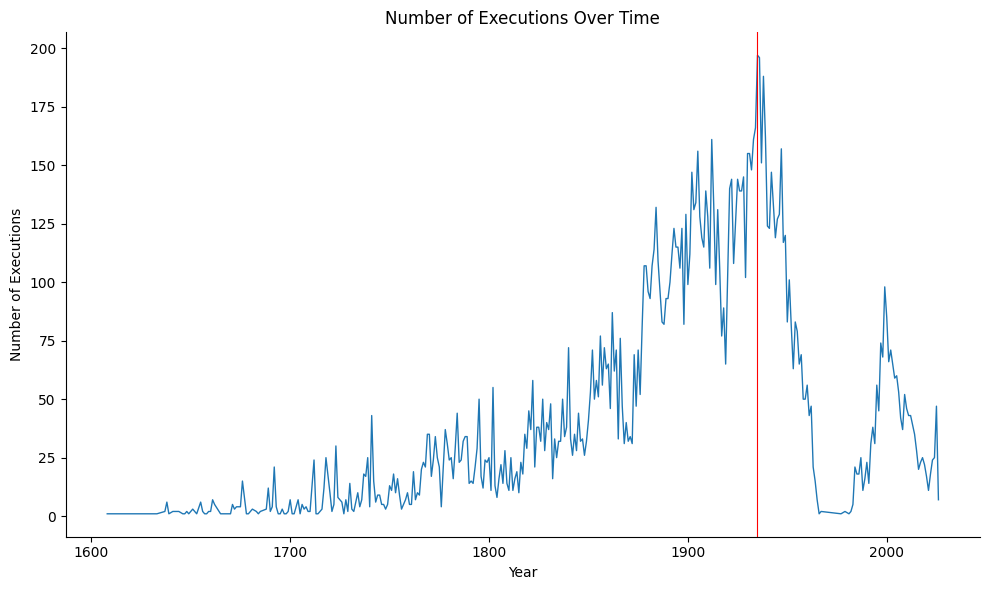

In [33]:
plt.figure(figsize=(10,6))
plt.plot(
    execution_trend.index,
    execution_trend.values,
    linewidth = .99)

plt.xlabel('Year')
plt.ylabel('Number of Executions')
plt.title('Number of Executions Over Time')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axvline(
    1935,
    color = "red",
    linewidth = .8
)

plt.tight_layout()
plt.show()

In [34]:
# get victim race value count


In [35]:
# do age column value counts and plot histogram
df_h_age_clean = df_h_pre1977.drop(df_h_pre1977[df_h_pre1977['age'] == 0].index)
df_h_age_clean.head()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
13065,White,Male,21,HAYLE THOMAS,Rape,Hanging,6,,1626,VA,Unknown
5795,White,Male,40,BILLINGTON JOHN,Murder,Hanging,30,9,1630,MA,Unknown
5802,White,Male,18,HACKETT WILLIAM,Sodmy-Buggry-Bst,Hanging,10,12,1641,MA,593
5803,White,Male,17,GRAUNGER THOMAS,Sodmy-Buggry-Bst,Hanging,,,1642,MA,593
5805,White,Female,18,LATHAM MARY,Adultery,Hanging,21,3,1643,MA,Housewife


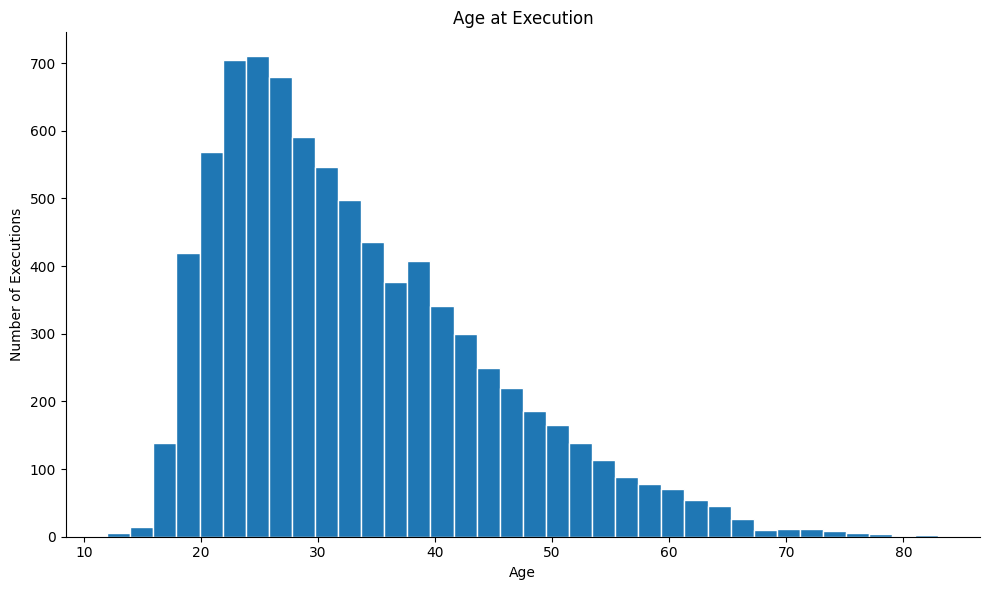

In [36]:
age_combined = pd.concat([df_h_age_clean['age'], df_m['Age']])

plt.figure(figsize=(10,6))
plt.hist(
    age_combined,
    edgecolor = "white",
    bins = 36
)

plt.xlabel("Age")
plt.ylabel("Number of Executions")
plt.title("Age at Execution")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [37]:
age_combined.describe()

count    8221.000000
mean       33.046223
std        11.516498
min        12.000000
25%        24.000000
50%        30.000000
75%        40.000000
max        83.000000
dtype: float64

In [38]:
methods_combined = pd.concat([
    df_h_pre1977[['date_year', 'exec_method']].rename(columns={'date_year': 'year', 'exec_method': 'method'}),
    df_m[['year', 'Method']].rename(columns={'Method': 'method'})], ignore_index=True)
method_counts_combo = methods_combined['method'].value_counts().sort_values(ascending=False)

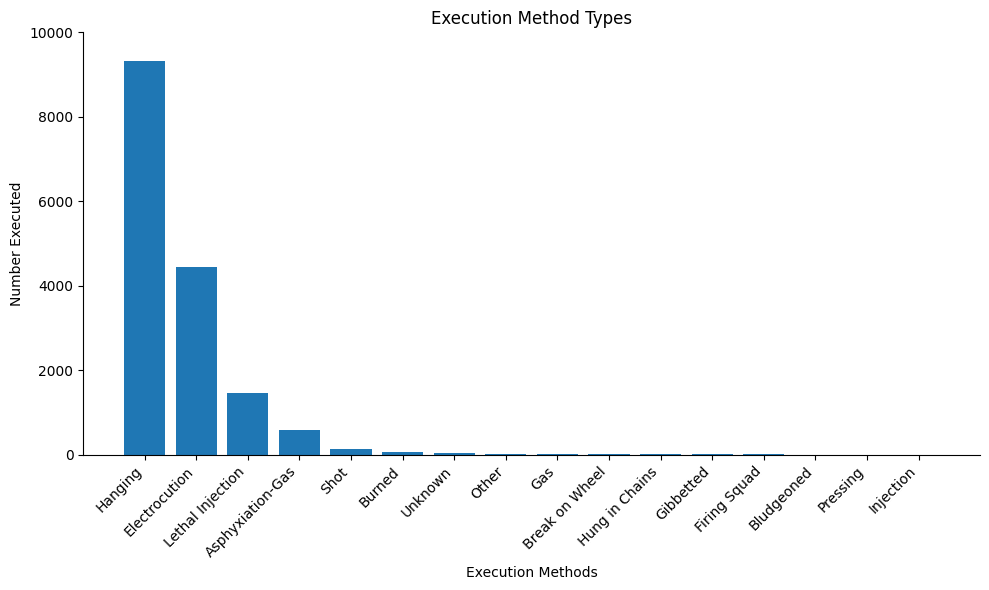

In [39]:
plt.figure(figsize=(10,6))
plt.bar(method_counts_combo.index, method_counts_combo.values)
plt.xticks(rotation=45, ha="right")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Execution Methods')
plt.ylabel('Number Executed')
plt.title('Execution Method Types')

plt.ylim(0, 10000)
plt.tight_layout()
plt.show()

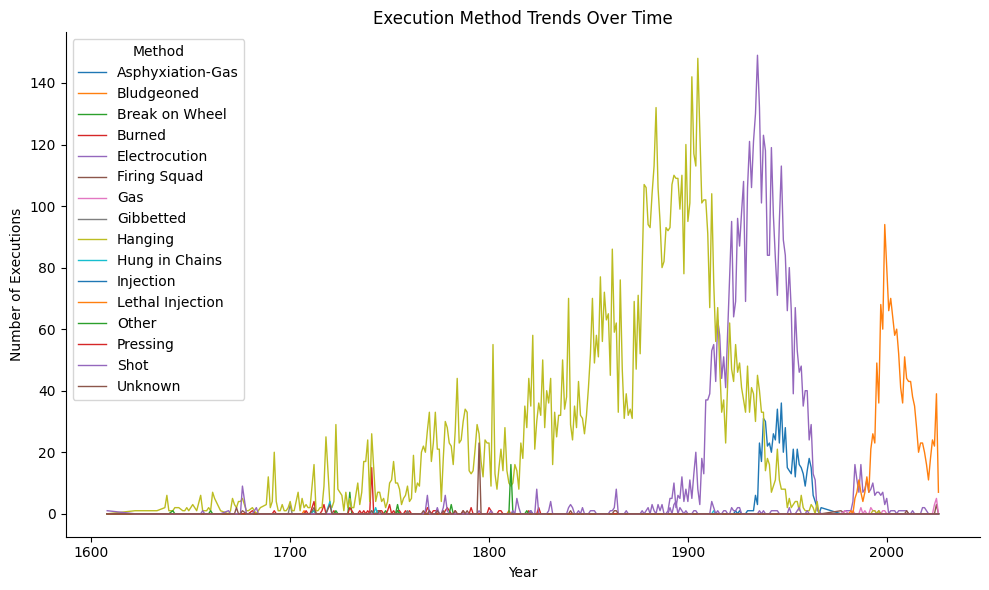

In [40]:
method_trends = methods_combined.groupby(['year', 'method']).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(10,6))

for method in method_trends.columns:
    plt.plot(method_trends.index, method_trends[method], label=method, linewidth=1)

plt.xlabel('Year')
plt.ylabel('Number of Executions')
plt.title('Execution Method Trends Over Time')
plt.legend(title='Method')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

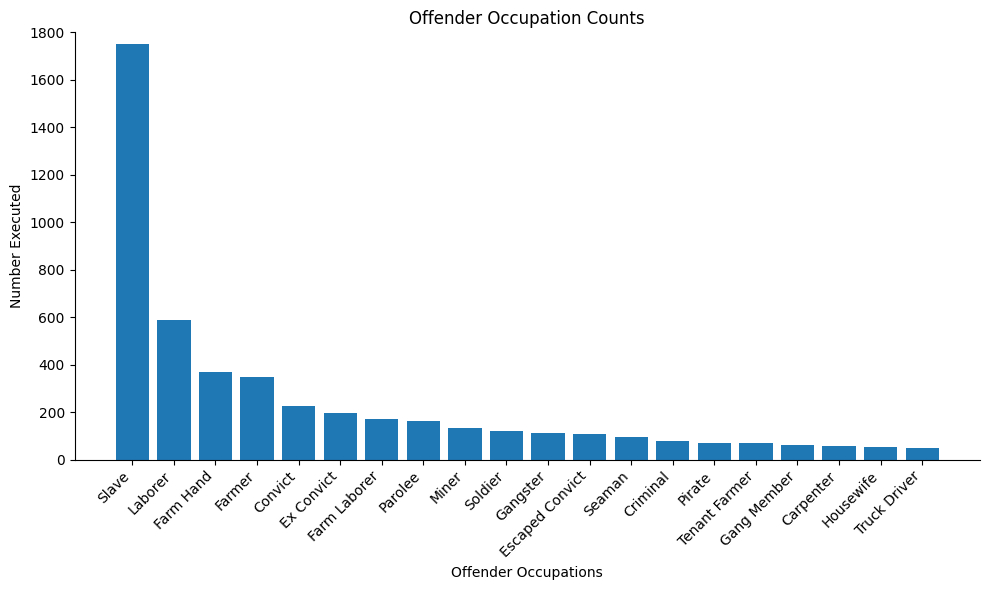

In [51]:
off_occ_clean = df_h.drop(df_h[df_h['off_occ'] == 'Unknown'].index)
off_occ_top_20 = off_occ_clean['off_occ'].value_counts().head(20)

plt.figure(figsize=(10,6))
plt.bar(off_occ_top_20.index, off_occ_top_20.values)
plt.xticks(rotation=45, ha="right")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Offender Occupations')
plt.ylabel('Number Executed')
plt.title('Offender Occupation Counts')

plt.ylim(0, 1800)
plt.tight_layout()
plt.show()

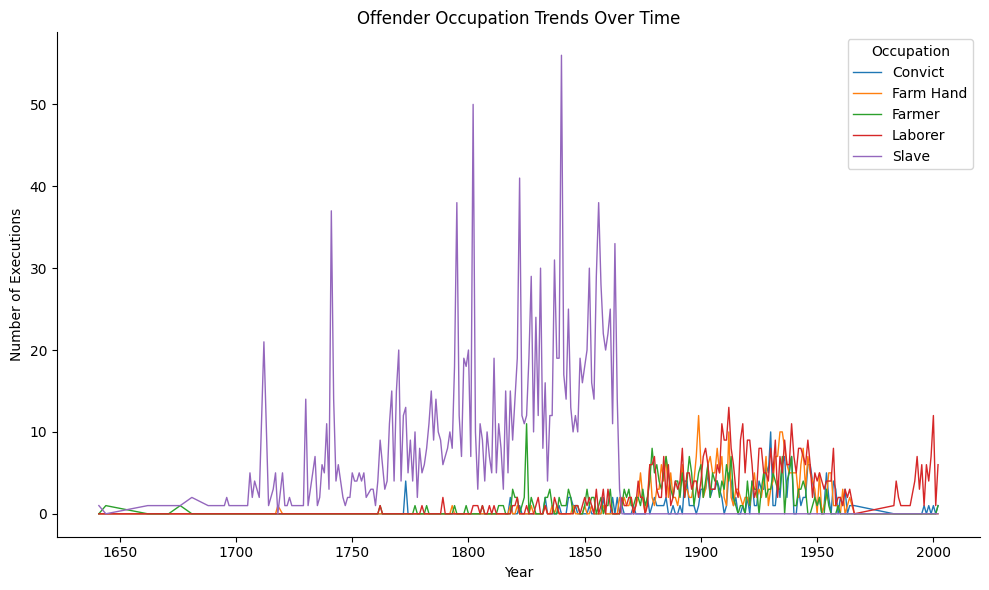

In [53]:
off_occ_top_5 = off_occ_clean['off_occ'].value_counts().head(5)
off_occ_clean = off_occ_clean[off_occ_clean['off_occ'].isin(off_occ_top_5.index)]
occupation_trends = off_occ_clean.groupby(['date_year', 'off_occ']).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(10,6))

for occupation in occupation_trends.columns:
    plt.plot(occupation_trends.index, occupation_trends[occupation], label=occupation, linewidth=1)

plt.xlabel('Year')
plt.ylabel('Number of Executions')
plt.title('Offender Occupation Trends Over Time')
plt.legend(title='Occupation')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()